# RMP2 Test
In this notebook we will test the RMP2 implementation against PySCF results for a variety of systems and basis sets.

In [1]:
from pyscf import gto, scf, mp
import numpy as np
from py_mods.src.MP2.CSMP2 import CS_MP2
# from py_mods.src.MP2.drafts.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.external import RHF_context_from_pyscf
import matplotlib.pyplot as plt

---

## He atom, cc-pvdz basis

In [2]:
# pyscf data
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": "aug-cc-pvqz",
}

mol = gto.M(**pyscf_args)

mf = scf.RHF(mol)

e_He = mf.kernel()
e_elec = mf.energy_elec()

mymp = mp.RMP2(mf).run()  # this is UMP2

converged SCF energy = -2.86152199563245
E(RMP2) = -2.89724612518338  E_corr = -0.0357241295509311
E(SCS-RMP2) = -2.90439095109357  E_corr = -0.0428689554611173


In [3]:
# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_res = CS_RHF(RHF_cxt)

# RHF_res.e_orb = mf.mo_energy
print(f"\nSCF energy: {RHF_res.E_RHF.real} (converged: {RHF_res.converged})")
print(f"SCF pyscf: {e_He}")
print(f"Difference: {RHF_res.E_RHF.real - e_He} \n")


SCF energy: -2.861521995632468 (converged: True)
SCF pyscf: -2.8615219956324482
Difference: -1.9539925233402755e-14 



In [4]:
# %%timeit
# mp_results = CS_MP2(RHF_res)

In [5]:
# %%timeit
# n_mp_results = naive_CS_MP2(RHF_res)

In [6]:
mp_results = CS_MP2(RHF_res)
# n_mp_results = naive_CS_MP2(RHF_res)

In [7]:
# print(
#     f"Difference between naive and tensor approach: {n_mp_results.E_MP2 - mp_results.E_MP2}"
# )
print(f"\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}")
print(f"MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}")
print(
    f"Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}"
)



MP2 calc: (-2.8972461251458856+0j), E_corr = (-0.03572412951341805-0j)
MP2 pyscf: -2.897246125183379, E_corr = -0.03572412955093105
Differences: (3.7493563809221087e-11+0j), E_corr = (3.751299965104593e-11-0j)


---

## Closed shell RMP2 for He, Mg, Ne, Ar, Kr atoms with aug-cc-pVTZ

In [8]:
basis = "aug-cc-pvtz"
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"{basis}",
}

atoms = [
    "He 0 0 0",
    "Mg 0 0 0",
    "Ne 0 0 0",
    "Ar 0 0 0",
    "Kr 0 0 0",
]

a_names = [i.strip().split()[0] for i in atoms]

abs_errors = []
rel_errors = []
n_electrons = []

for atom in atoms:
    pyscf_args["atom"] = atom
    mol = gto.M(**pyscf_args)
    mol.verbose = 0 

    mf = scf.RHF(mol)
    mf.conv_tol = 1e-14
    mf.conv_tol_grad = 1e-14

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)

    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

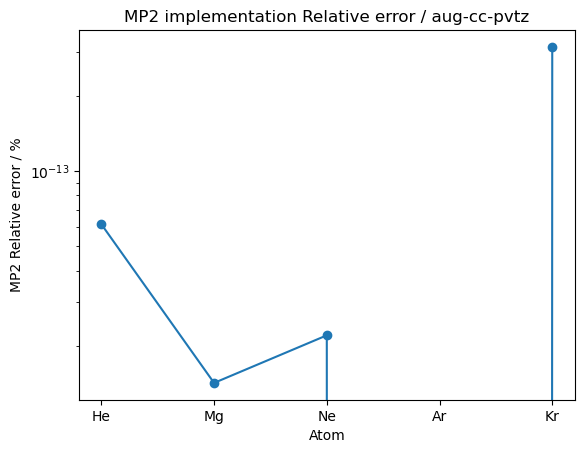

In [9]:
plt.plot(a_names, rel_errors, marker="o", linestyle="-")

plt.title(f"MP2 implementation Relative error / {basis}")
plt.yscale("log")
plt.ylabel("MP2 Relative error / %")
plt.xlabel("Atom")

plt.show()

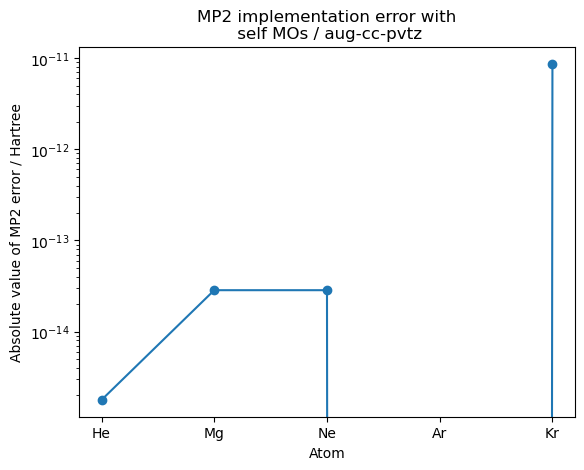

In [10]:
abs_errors = [abs(i) for i in abs_errors]
plt.plot(a_names, np.array(abs_errors).real, marker="o", linestyle="-")

plt.title(f"MP2 implementation error with\n self MOs / {basis}")
plt.yscale("log")
plt.ylabel("Absolute value of MP2 error / Hartree")
plt.xlabel("Atom")

plt.show()

In [11]:
print(abs_errors)
for tag, error in zip(a_names, abs_errors):
    print(
        f"|${tag}$| ${error:.1E}$ |".replace("E", " \\cdot 10^{").replace("$ |", "}$ |")
    )

[np.float64(1.7763568394002505e-15), np.float64(2.842170943040401e-14), np.float64(2.842170943040401e-14), np.float64(0.0), np.float64(8.640199666842818e-12)]
|$He$| $1.8 \cdot 10^{-15}$ |
|$Mg$| $2.8 \cdot 10^{-14}$ |
|$Ne$| $2.8 \cdot 10^{-14}$ |
|$Ar$| $0.0 \cdot 10^{+00}$ |
|$Kr$| $8.6 \cdot 10^{-12}$ |


The result difference is:
|Atom| $MP2$ Energy Error  |
|----|---------------------|
|$He$| $1.8 \cdot 10^{-15}$ |
|$Mg$| $2.8 \cdot 10^{-14}$ |
|$Ne$| $2.8 \cdot 10^{-14}$ |
|$Ar$| $0.0 \cdot 10^{+00}$ |
|$Kr$| $8.6 \cdot 10^{-12}$ |